In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
import numpy as np

import matplotlib.pyplot as plt
from mad.objs.constants import titan_stage_1, titan_stage_2, EARTH_SETTINGS
from mad.objs.planets import Planet, PlanetConfig
from mad.objs.common_schemas import MovableObject
from mad.objs.missiles import BallisticConfig, MissileStage, StageConfig, Guidance, BallisticMissile
from mad.logger import SourceLogger

logger = SourceLogger()

In [35]:
EARTH_SETTINGS["position"] = [0.0, 0.0]

earth = Planet(PlanetConfig(**EARTH_SETTINGS))

launchpad = earth.create_random_point(name="Launchpad")
target = earth.create_random_point_at_distance(launchpad, distance=7_000_000, name="Target")

earth.escape_velocity, earth.gravity_at_surface

(np.float64(11185.79353278485), np.float64(-9.819649737724955))

In [53]:
stage1 = MissileStage(StageConfig(**titan_stage_1))
stage2 = MissileStage(StageConfig(**titan_stage_2))

guidance = Guidance(cruise_altitude=1, target=target)
titan = BallisticMissile(BallisticConfig(position=launchpad.position.tolist(), stages=[stage1, stage2], name="Titan I", guidance=guidance))

f"dV={titan.deltav:.2f} m/s, range={titan.ballistic_range(earth, gamma_deg=45)/1000:4.2f} km"

'dV=11818.37 m/s, range=15169.85 km'

In [54]:
dt = 1
active_objs = [titan]
inactive_objs = []
for t in range(20000):
    new_objects = []

    for obj in active_objs[:]:

        if not obj.active:
            continue

        sim_update = obj.update(dt)

        if sim_update is not None:
            new_objects.append(sim_update)
            logger["Simulation"].info(f"{sim_update.name} added to Simulation.")

        if not obj.active:
            continue
        obj.integrate(dt, earth)




    active_objs.extend(new_objects)

0.9999999998358784
0.9999999998358784
0.9999999973865497
0.9999999973865498
0.9999999868337389
0.9999999868337386
0.9999999585947928
0.999999958594793
0.9999998994258785
0.9999998994258787
0.9999997925299265
0.9999997925299284
0.9999996176693456
0.9999996176693502
0.9999993512835079
0.9999993512835197
0.9999989666110328
0.9999989666110602
0.9999984338168698
0.9999984338169254
0.9999977201242001
0.9999977201243071
0.999996789951174
0.9999967899513684
0.9999956050524897
0.999995605052824
0.9999941246658306
0.9999941246663837
0.9999923056631818
0.9999923056640624
0.9999901027070263
0.9999901027083863
0.9999874684114526
0.9999874684134942
0.9999843535081705
0.9999843535111622
0.999980707017469
0.9999807070217561
0.9999764764241125
0.9999764764301371
0.9999716078582104
0.9999716078665278
0.9999660462810604
0.9999660462923616
0.9999597356759936
0.9999597356911267
0.99995261924423
0.9999526192642277
0.9999446396057677
0.9999446396318731
0.9999357390053187
0.9999357390390187
0.9999258595233133

In [55]:
def extract_history(objs:list):

    results = {}
    for obj in objs:
        pos = np.asarray(obj.history.position)
        vel = np.asarray(obj.history.velocity)
        time = np.asarray(obj.history.time)

        posx, posz = pos[:, 0], pos[:, 1]
        velx, velz = vel[:, 0], vel[:, 1]

        altitude = np.sqrt(posx**2 + posz**2) - earth.radius
        velout = np.sqrt(velx**2 + velz**2)

        results[obj.name] = {"time": time, "altitude": altitude, "velocity":velout, "posx":posx, "posz":posz}

    return results

results = extract_history(active_objs)
results.keys()

dict_keys(['Titan I', 'Stage1', 'Stage2'])

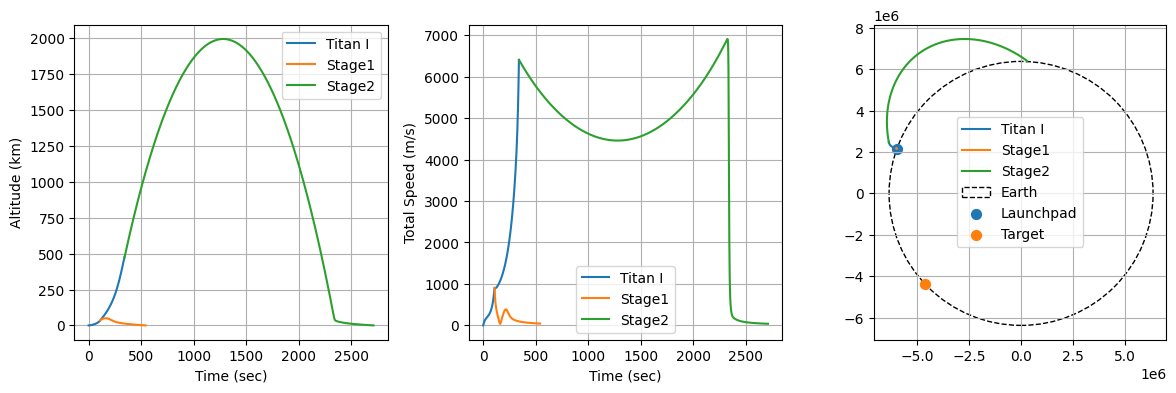

In [56]:
fig, ax = plt.subplots(ncols=3, nrows=1, figsize=(12, 4))
ax.flatten()

maxx, maxz = 0.0, 0.0
minx, minz= 0.0, 0.0
for obj, result in results.items():

    ax[0].plot(result["time"], result["altitude"] / 1000, label=obj)
    ax[1].plot(result["time"], result["velocity"], label=obj)
    ax[2].plot(result["posx"], result["posz"], label=obj)
    
ax[1].set_xlabel("Time (sec)")
ax[1].set_ylabel("Total Speed (m/s)")
ax[1].legend()
ax[1].grid()

ax[0].set_xlabel("Time (sec)")
ax[0].set_ylabel("Altitude (km)")
ax[0].grid()
ax[0].legend()

earth.plot_2D_with_points(points = [launchpad, target], ax=ax[2])


fig.tight_layout(pad=1.2)

In [25]:
f"Distance Impact to target: {earth.surface_distance(target, active_objs[2]) / 1000:.2f} km"

'Distance Impact to target: 1100.38 km'